### K-Means For Iris Dataset

In [1]:
# The Iris dataset is one of the most famous datasets in machine learning, commonly used for classification and clustering practice

# Basic Information
# Total samples: 150
# Features: 4
# Target classes: 3 types of flowers

# Target Classes (Species)
# Setosa
# Versicolor
# Virginica

# Setosa is linearly separable because its feature values are clearly distinct from the other classes, 
# whereas Versicolor and Virginica have overlapping features, making them harder to separate and their clusters lie closer together

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [3]:
iris = load_iris()

In [4]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names

In [5]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
X = iris.data
y = iris.target

<Axes: >

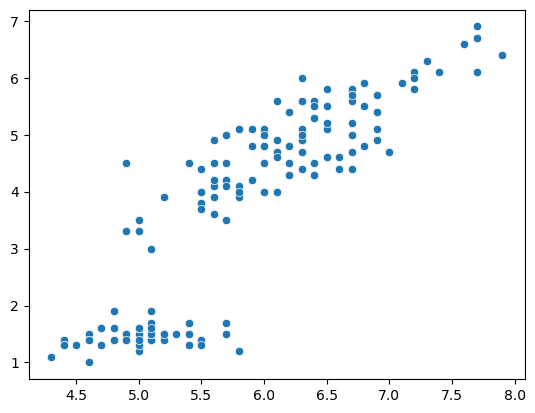

In [7]:
# Visualization:
# The Iris dataset has 4 features, but visualizing all 4 at once is not possible.
# So, we use only 2 features to get a basic idea of how the data points are distributed.
sns.scatterplot(x=X[:,0], y=X[:,2]) # X[:, 0] selects all rows of the first feature (column 0) and X[:, 2] selects all rows of the third feature (column 2)

In [8]:
# We can see that one cluster is clearly visible, which corresponds to the Setosa class
# However, the other two classes, Versicolor and Virginica, are overlapping, so they are not well separated

In [9]:
# **IMPORTANT**
# The Elbow Method and Silhouette Score do not tell us how many actual classes exist in the data
# Instead, they measure how well the data points are separated into clusters. Based on this separation, they suggest the optimal value of K

# For example, in the Iris dataset, we know there are 3 classes, so ideally we expect the data to be divided into 3 clusters, 
# meaning the Elbow Method and Silhouette Score should suggest K = 3.
# However, we can see that one cluster is clearly visible, corresponding to the Setosa class, while the other two classes, 
# Versicolor and Virginica, overlap and are not well separated.
# In such cases, where some clusters are clearly separable but others overlap, the Elbow Method and Silhouette Score may suggest 
# an optimal value of K = 2 instead of 3

In [10]:
# Feature scaling is required for KMeans to ensure all features contribute equally to distance calculations
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Since we know that the optimal value of K is 3, let's verify it using the Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

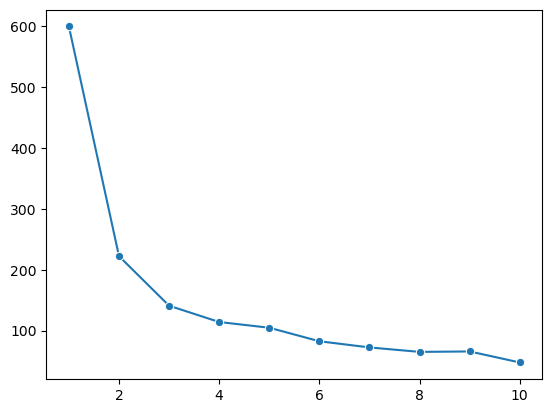

In [12]:
sns.lineplot(x=range(1, 11), y=wcss, marker='o')

In [13]:
# Observation
# Look at how WCSS decreases as K increases:

# Big drop from K = 1 → 2
# Still noticeable drop from K = 2 → 3
# After K = 3, the curve starts to flatten

# The elbow point is around K = 3, indicating the optimal number of clusters
# However, a slight bend can also be observed at K = 2
# Since we know that the Iris dataset contains 3 classes, we choose K = 3 as the final number of clusters

C:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

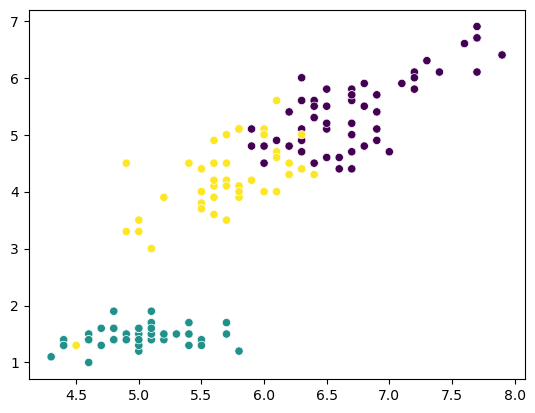

In [14]:
# KMeans

kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(X_scaled) # labels = cluster number assigned to each data point

sns.scatterplot(x=X[:, 0], y=X[:,2], c=labels)
# wec an observe that Setosa is clearly separated, while Versicolor and Virginica overlap

## Dimensionality Reduction

In [15]:
# Dimensionality reduciton using PCA
from sklearn.decomposition import PCA # using PCA (Principal Component Analysis) to reduce dimensions of data

pca = PCA(n_components=2) # want to reduce data to 2 dimensions (2 features)

pca_data = pca.fit_transform(X_scaled) # The transformed data(pca_data) will now have 2 features (principal components)

C:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

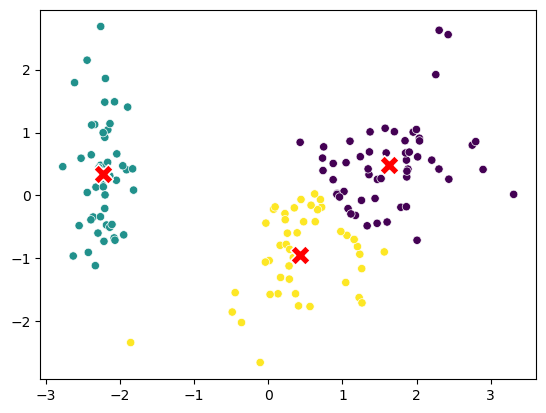

In [16]:
# KMeans

kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data) # labels = cluster number assigned to each data point

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="X", c="red", s=200)
# The red 'X' markers represent the centroids of the clusters, located at the center,
# as they are the mean position of all data points in each cluster.

### Observations

In [17]:
# a) Before PCA
# Setosa cluster is clearly separated
# Versicolor and Virginica overlap
# Clusters are not perfectly separable

# b) After PCA
# Data is reduced to 2 dimensions (PC1 & PC2)
# Clusters are more visually clear
# Setosa still clearly separated 
# Versicolor and Virginica are still overlapping, but separation looks slightly better organized

### Key Insight

In [18]:
# PCA does not remove overlap completely but improves visualization and spreads data better
# After applying PCA, the data becomes easier to visualize in 2D, clusters appear more structured, but overlapping between 
# some classes (Versicolor and Virginica) still remains